In [15]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np
import os
import json

# node2vec
from node2vec import Node2Vec

# clustering
from sklearn.cluster import KMeans, DBSCAN

# deep stuff
import torch
from torch_geometric.utils import from_networkx

In [16]:
from community_results import community_metrics, plot_communities
from graph_based_clustering import label_propagation, louvain, leiden
from DGIModel import DGIModel

# Load dataset

In [17]:
data_path = './data/deezer_clean_data/'

edges = os.path.join(data_path, 'HR_edges.csv')
genres = os.path.join(data_path, 'HR_genres.json')

In [31]:
edges_df = pd.read_csv(edges)
g = nx.from_pandas_edgelist(edges_df, source='node_1', target='node_2')

In [19]:
with open(genres, 'r') as f:
    genres_data = json.load(f)


In [43]:
def encode_genres(genre_list, unique_genres):
    encoding = [1 if genre in genre_list else 0 for genre in unique_genres]
    return encoding


def decode_genres(genre_vector, unique_genres):
    decoded_genres = [unique_genres[i] for i in range(len(genre_vector)) if genre_vector[i] == 1]
    return decoded_genres

In [44]:
all_genres = set()
for genres in genres_data.values():
    all_genres.update(genres)

all_genres = sorted(all_genres)

for user_id, genres in genres_data.items():
    if isinstance(user_id, str):
        user_id = int(user_id)
    if user_id in g.nodes:
        g.nodes[user_id]['genres'] = encode_genres(genres, all_genres)

In [46]:
sel_graph = 'deezer'
# nx.draw(g, with_labels=True)

# Apply graph based clustering

## Label Propagation

In [47]:
lp_labels = label_propagation(g)

plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}")

# Calculate metrics for Louvain
lp_metrics = community_metrics(g, lp_labels)
lp_metrics

## Louvain

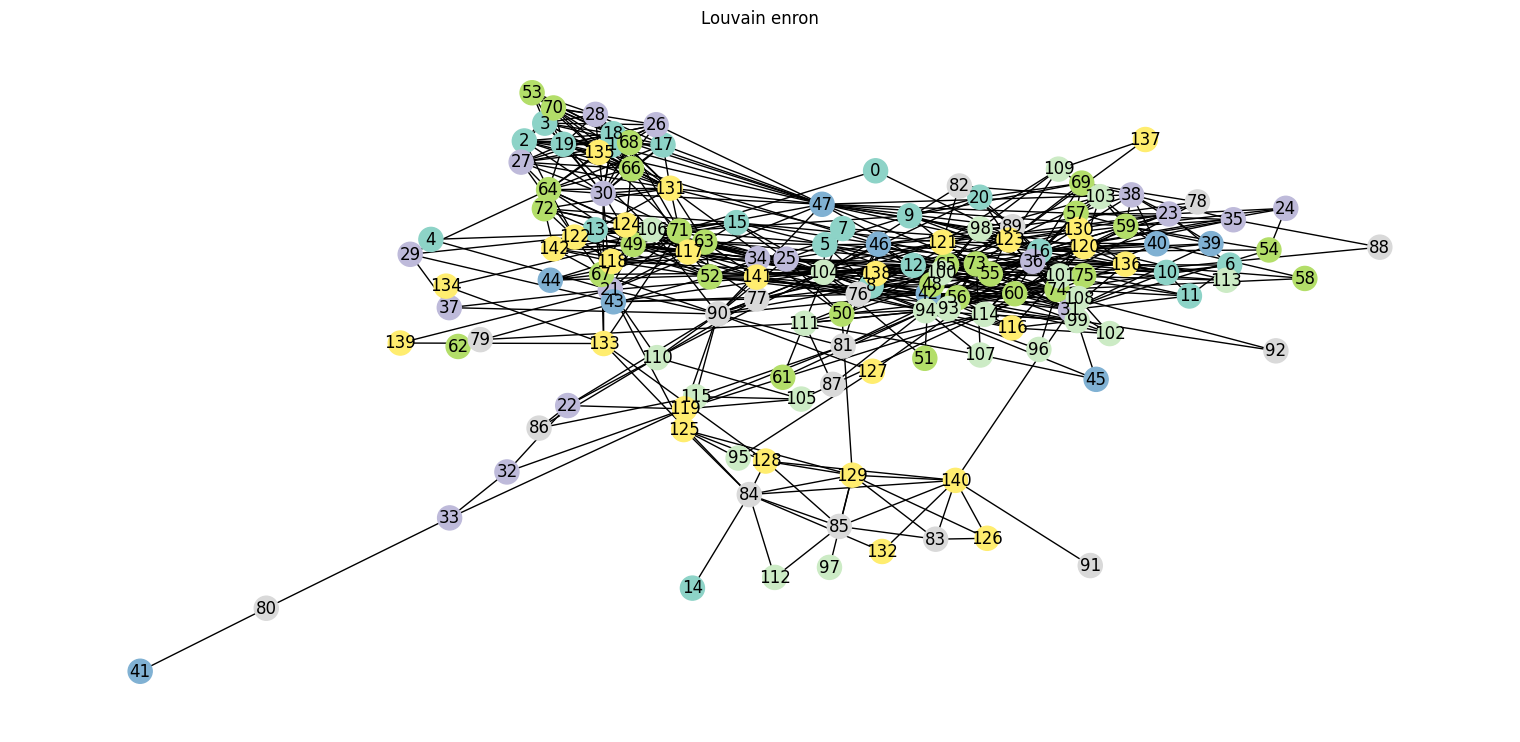

{'Number of Communities': 7,
 'Average Community Size': 20.428571428571427,
 'Modularity': 0.5618351115222,
 'Coverage': 0.7383627608346709,
 'Performance': 0.8798384713877672}

In [ ]:
lv_labels = louvain(g)

plot_communities(g, lv_labels, title=f"Louvain {sel_graph}")

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_metrics

## Leiden

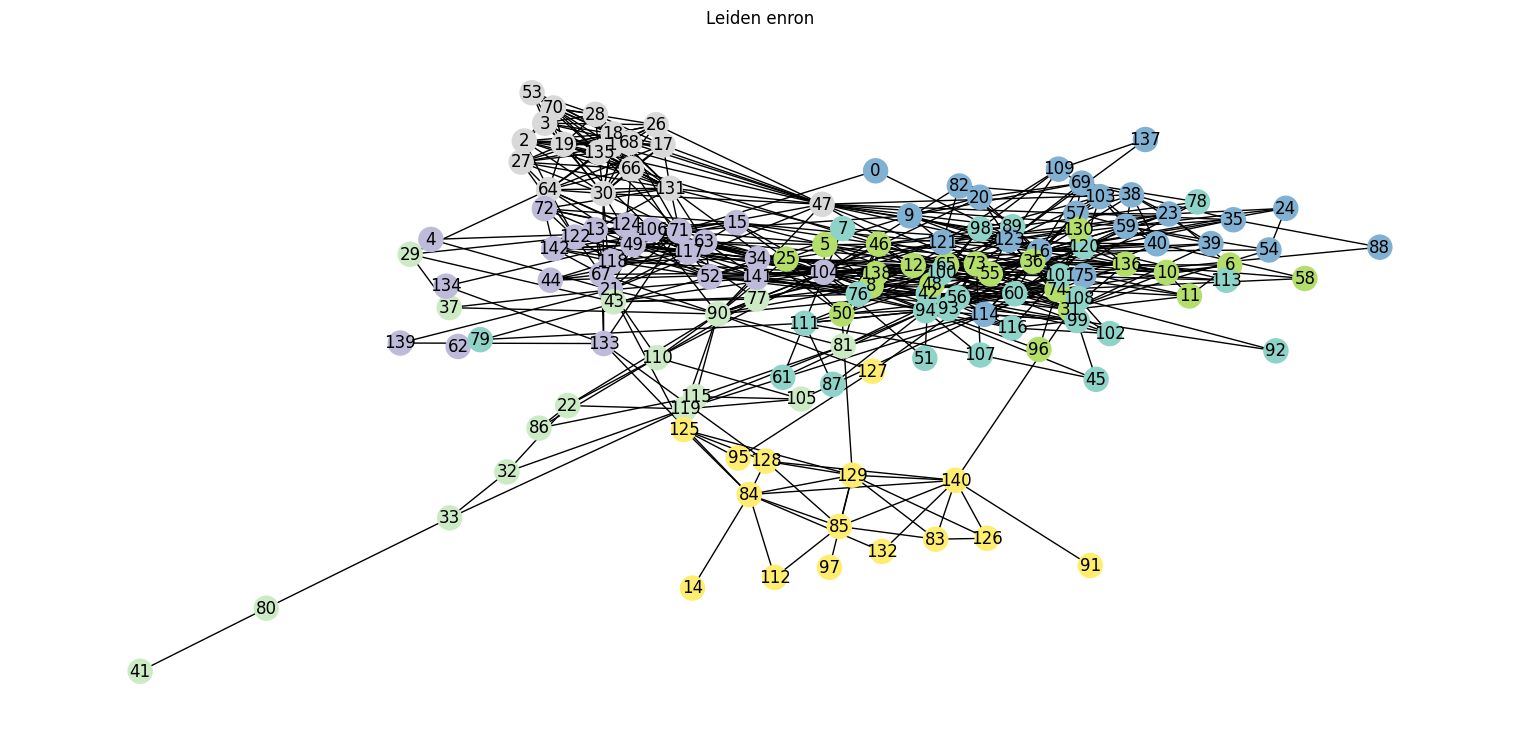

{'Number of Communities': 7,
 'Average Community Size': 20.428571428571427,
 'Modularity': 0.5678678995900848,
 'Coverage': 0.7335473515248796,
 'Performance': 0.886634492268295}

In [ ]:
ld_labels = leiden(g)

plot_communities(g, ld_labels, title=f"Leiden {sel_graph}")

# Calculate metrics for Louvain
ld_metrics = community_metrics(g, ld_labels)
ld_metrics

# node2vec

In [ ]:
node2vec = Node2Vec(g, dimensions=64, walk_length=20, num_walks=100, workers=4) 

# Embed nodes
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)

Generating walks (CPU: 4): 100%|██████████| 25/25 [00:00<00:00, 27.24it/s]


## Clustering using node2vec only

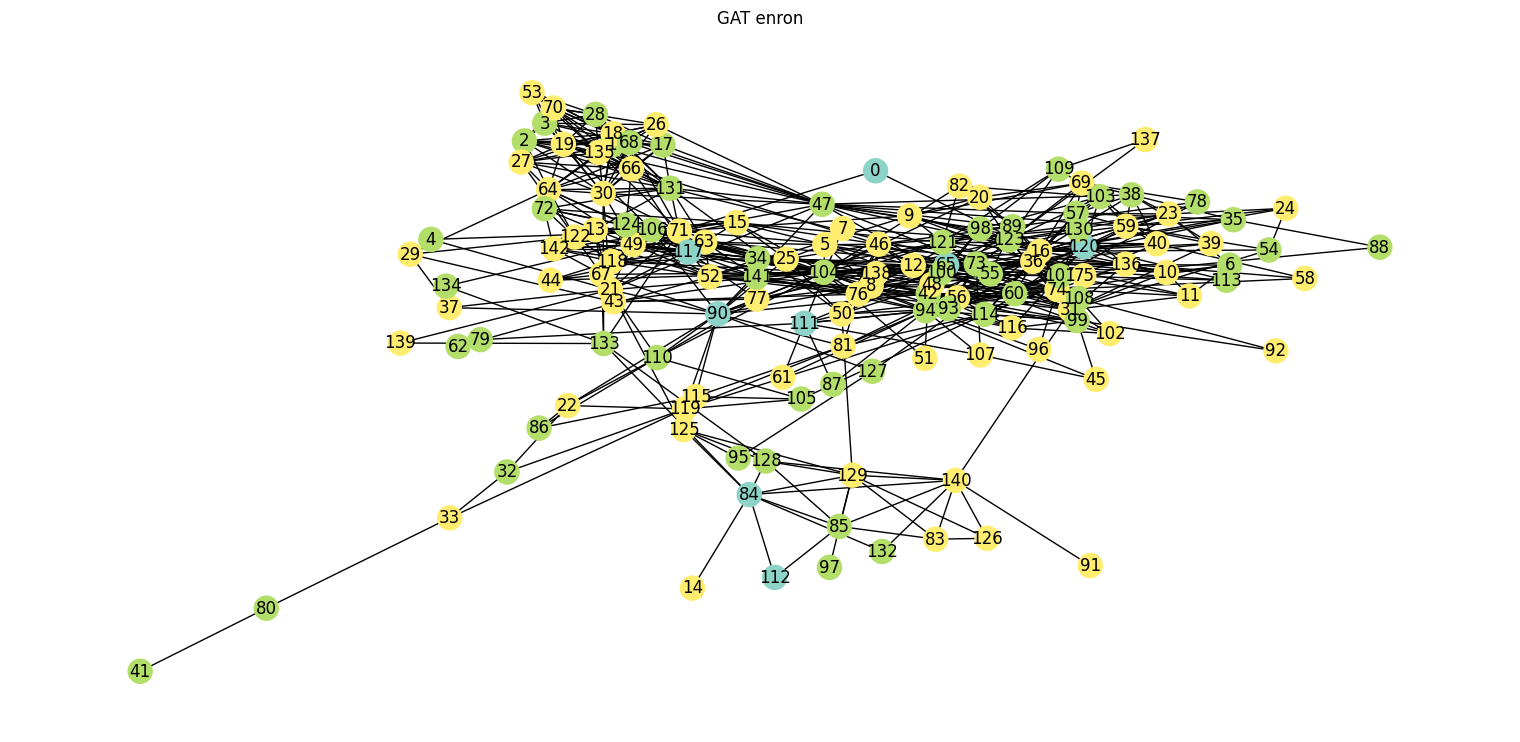

{'Number of Communities': 3,
 'Average Community Size': 47.666666666666664,
 'Modularity': 0.0183650281220934,
 'Coverage': 0.47030497592295345,
 'Performance': 0.5425982468235989}

In [48]:
best_eps = 0
best_mod = -1

for i in np.arange(0.1, 1.0, 0.01):
    dbscan = DBSCAN(eps=i, min_samples=5)
    communities = dbscan.fit_predict(node2vec_model.wv.get_normed_vectors())
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_eps, best_mod = i, mod


dbscan = DBSCAN(eps=best_eps, min_samples=5)
communities = dbscan.fit_predict(node2vec_model.wv.get_normed_vectors())
plot_communities(g, communities, title=f"node2vec {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

# Apply GAT Embedding

In [49]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

Epoch 0, Loss: 1.379037618637085
Epoch 10, Loss: 1.3762609958648682
Epoch 20, Loss: 1.370748519897461
Epoch 30, Loss: 1.3694095611572266
Epoch 40, Loss: 1.3578344583511353
Epoch 50, Loss: 1.3101356029510498
Epoch 60, Loss: 1.2890689373016357
Epoch 70, Loss: 1.2839572429656982
Epoch 80, Loss: 1.191519021987915
Epoch 90, Loss: 1.198696494102478
Epoch 100, Loss: 1.0903339385986328
Epoch 110, Loss: 1.0215423107147217
Epoch 120, Loss: 0.9188525676727295
Epoch 130, Loss: 0.8037121891975403
Epoch 140, Loss: 0.9101254343986511
Epoch 150, Loss: 0.7007156014442444
Epoch 160, Loss: 0.7674589157104492
Epoch 170, Loss: 0.7320957779884338
Epoch 180, Loss: 0.6104161739349365
Epoch 190, Loss: 0.6446706056594849
Epoch 200, Loss: 0.47582292556762695
Epoch 210, Loss: 0.6243570446968079
Epoch 220, Loss: 0.508664608001709
Epoch 230, Loss: 0.46470221877098083
Epoch 240, Loss: 0.4663236737251282
Epoch 250, Loss: 0.3900664150714874
Epoch 260, Loss: 0.6057555079460144
Epoch 270, Loss: 0.4741560220718384
Epoch 

In [50]:
model = DGIModel(in_channels=data.num_features, out_channels=16, dropout=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

# Training the model
for epoch in range(800):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')


In [ ]:
# Extract node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model.encoder(data.x, data.edge_index)

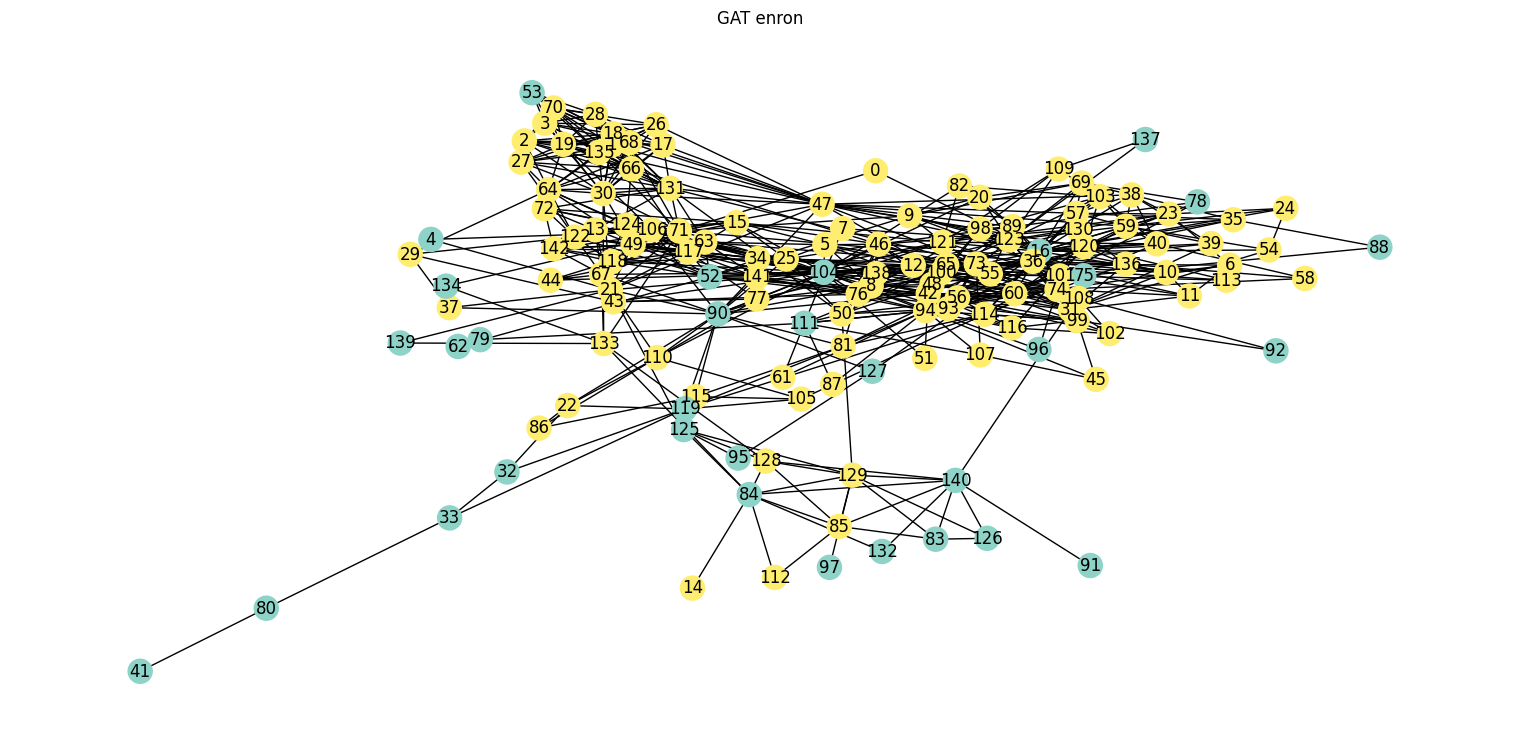

{'Number of Communities': 2,
 'Average Community Size': 71.5,
 'Modularity': 0.03463152714690208,
 'Coverage': 0.7640449438202247,
 'Performance': 0.38225155126563576}

In [51]:
best_eps = 0
best_mod = -1

for i in np.arange(0.1, 1.0, 0.01):
    dbscan = DBSCAN(eps=i, min_samples=5)
    communities = dbscan.fit_predict(node_embeddings.detach().cpu().numpy())
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_eps, best_mod = i, mod


dbscan = DBSCAN(eps=best_eps, min_samples=5)
communities = dbscan.fit_predict(node_embeddings.detach().cpu().numpy())
plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))

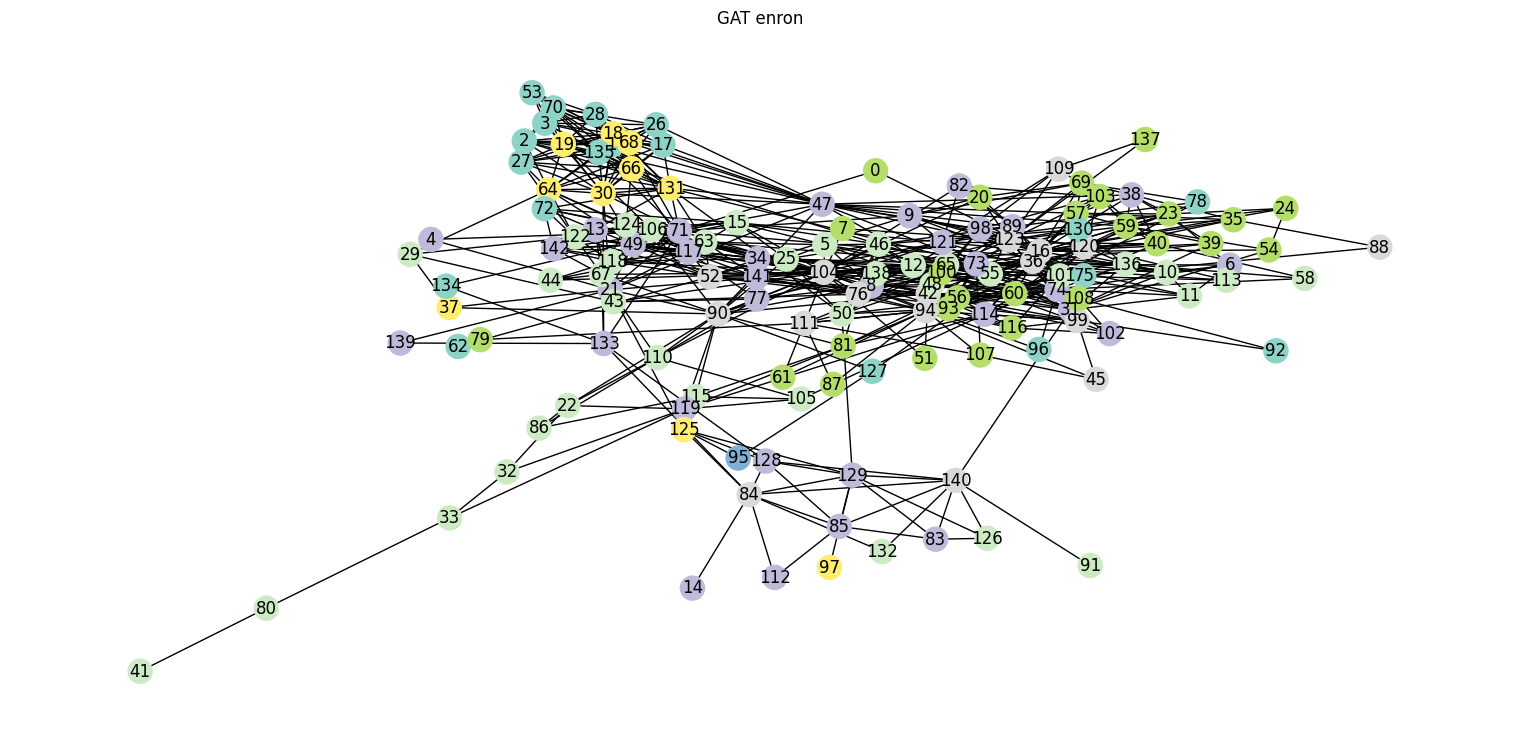

{'Number of Communities': 7,
 'Average Community Size': 20.428571428571427,
 'Modularity': 0.13588136933854464,
 'Coverage': 0.32102728731942215,
 'Performance': 0.7937555402344135}

In [52]:
best_n = 0
best_mod = -1

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i)
    communities = kmeans.fit_predict(node_embeddings.detach().cpu().numpy())
    mod = community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))['Modularity']
    if mod > best_mod:
        best_n, best_mod = i, mod

kmeans = KMeans(n_clusters=best_n)  # The Karate Club graph has two main communities
communities = kmeans.fit_predict(node_embeddings.detach().cpu().numpy())

plot_communities(g, communities, title=f"GAT {sel_graph}")
community_metrics(g, dict(zip(range(g.number_of_nodes()), communities)))